In [6]:
import os
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, OrdinalEncoder
from sklearn.model_selection import LeaveOneOut, KFold, cross_val_predict,RandomizedSearchCV,GridSearchCV
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.kernel_ridge import KernelRidge
from sklearn.inspection import permutation_importance
from sklearn.pipeline import Pipeline,make_pipeline
from xgboost import XGBRegressor
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, WhiteKernel, Matern, ConstantKernel as C,DotProduct, RationalQuadratic
from sklearn.neural_network import MLPRegressor
from sklearn.linear_model import LinearRegression, Ridge, Lasso

# 容错导入SHAP
try:
    import shap
except Exception as e:
    print(f"SHAP导入失败: {e}")
    shap = None

import warnings
warnings.filterwarnings("ignore")

SHAP导入失败: initialization of _internal failed without raising an exception


In [3]:
# 设置绘图风格
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['font.sans-serif'] = ['SimHei'] # 显示中文
plt.rcParams['axes.unicode_minus'] = False

In [4]:
# 初始准备工作
# 1.读取清洗好的数据
file_path = "Final_Features_Ultimate_all_deletion.csv" 
df = pd.read_csv(file_path)

In [26]:
# 2. 定义特征组 (严格对齐新版 CSV 列名)

# A. 力学特征组 (用于预测 Strength, Elongation)
# 包含：用量层 + 身份层 + 机理层
features_mech = [
    # --- 1. 用量层 (Dosage) ---
    'X1_Soft_Content',      # 软段含量 (原 X1_SoftSeg)
    'X2_DA_Content',        # DA单体含量
    'X3_Hard_Content',      # 硬段含量 (原 X3_HardSeg)
    'X4_R_Ratio',           # 异氰酸酯指数
    'X5_Add_Crosslink',     # 额外非DA交联剂含量 (原 X5_Crosslink)
    
    # --- 2. 身份层 (Identity) ---
    'DA_Linker_Type',       # 0=无, 1=糠胺, 2=糠醇 (替代原来的 DA_KA/KC)
    'Network_Topology',     # 0=主链, 1=侧链 (替代原来的 cross_class)
    'Polyol_Class',         # 0=聚醚, 1=聚酯 (替代 Polyol_Type)
    'Iso_Class',            # 0=脂肪族, 1=芳香族 (替代 Iso_Type 1-5分)
    
    # --- 3. 机理层 (Mechanism) ---
    'Soft_Mw',              # 软段分子量
    'Constraint_Factor',    # 冻结因子 (关键!)
    'Hard_Symmetry',        # 硬段对称性
    'Soft_Cryst',           # 软段结晶性
    'Synergy_Feature'       # 结晶协同因子
    # 注意：Extender_Class、Add_Crosslinker_Flag 已删除（与 X5_Add_Crosslink 完全相关 r=1.0）
]

# B. 愈合特征组 (用于预测 Healing Efficiency)
# 包含：力学特征 + 工艺参数 (温度、时间)
features_heal = features_mech + ['healing_temperature', 'healing_time']

# 3. 二次清洗 (逻辑保持不变)
def get_clean_data(target_col, feature_cols, df):
    """
    清洗数据：仅保留目标值和特征值都不为空的行
    """
    # 检查列是否存在，防止报错
    missing_cols = [c for c in feature_cols if c not in df.columns]
    if missing_cols:
        raise ValueError(f"以下特征在 CSV 中找不到，请检查列名拼写: {missing_cols}")

    # 剔除空值
    data = df.dropna(subset=[target_col] + feature_cols).copy()
    
    X = data[feature_cols].values
    y = data[target_col].values
    
    return X, y

# 4. 定义评估函数 (逻辑保持不变)
def evaluate_model(model, X, y, task_name="Task"):
    # 使用 LOOCV (留一法) 适合小样本 (<100)
    cv = LeaveOneOut() 
    
    # 预测
    # 注意：如果使用 GP 或 NeuralNet，建议在 Pipeline 里加 StandardScaler
    y_pred = cross_val_predict(model, X, y, cv=cv, n_jobs=-1)
    
    r2 = r2_score(y, y_pred)
    rmse = np.sqrt(mean_squared_error(y, y_pred))
    
    return r2, rmse, y_pred

# 5. 检查与验证
print("特征组定义完毕！")
print(f"力学模型特征数: {len(features_mech)}")
print(f"自愈合模型特征数: {len(features_heal)}")

# 尝试打印前5行看看是否报错 (检查列名匹配)
try:
    print("\n特征数据概览 (前5行):")
    print(df[features_mech].head())
    print(f"\n有效总样本数: {len(df)}")
except KeyError as e:
    print(f"\n❌ 错误：CSV列名不匹配！请检查上一轮生成的 CSV 文件。报错列名: {e}")
except NameError:
    print("\n⚠️ 提示：df 尚未加载，请先读取 CSV 文件。")

特征组定义完毕！
力学模型特征数: 14
自愈合模型特征数: 16

特征数据概览 (前5行):
   X1_Soft_Content  X2_DA_Content  X3_Hard_Content  X4_R_Ratio  \
0           0.6607         0.1924           0.1469      0.5000   
1           0.6825         0.1658           0.1517      0.5333   
2           0.4880         0.0800           0.4320      0.9677   
3           0.6651         0.0000           0.3349      1.3333   
4           0.5592         0.0000           0.4078      1.0000   

   X5_Add_Crosslink  DA_Linker_Type  Network_Topology  Polyol_Class  \
0             0.000               2                 0             1   
1             0.000               2                 0             1   
2             0.000               2                 1             0   
3             0.000               0                 0             0   
4             0.033               0                 0             0   

   Iso_Class  Soft_Mw  Constraint_Factor  Hard_Symmetry  Soft_Cryst  \
0          0   2000.0             0.0001              0 

Pearson 相关性分析

[方案1] 力学性能相关性分析（特征 + tensile_strength + elongation）
--------------------------------------------------------------------------------
有效样本数: 84
分析维度: 14 特征 + 2 目标 = 16 维

✅ 关键发现1: tensile_strength ↔ elongation 相关系数 = 0.221
   → 正相关，两者可以协同优化

✅ 关键发现2: 特征间高度相关（|r| > 0.85，可能存在冗余）
   X3_Hard_Content ↔ Constraint_Factor: 0.856

✅ 关键发现3: 特征与性能的线性相关性（|r| < 0.5 说明需要非线性模型）

   tensile_strength 的 Top 3 线性相关特征:
      X3_Hard_Content: 0.653
      Soft_Cryst: 0.594
      Constraint_Factor: 0.435

   elongation 的 Top 3 线性相关特征:
      X2_DA_Content: 0.425
      Hard_Symmetry: 0.414
      Iso_Class: 0.336
   → 最强线性相关仅 0.425，说明关系非线性，需要 SVR/GPR/MLP 等非线性模型！


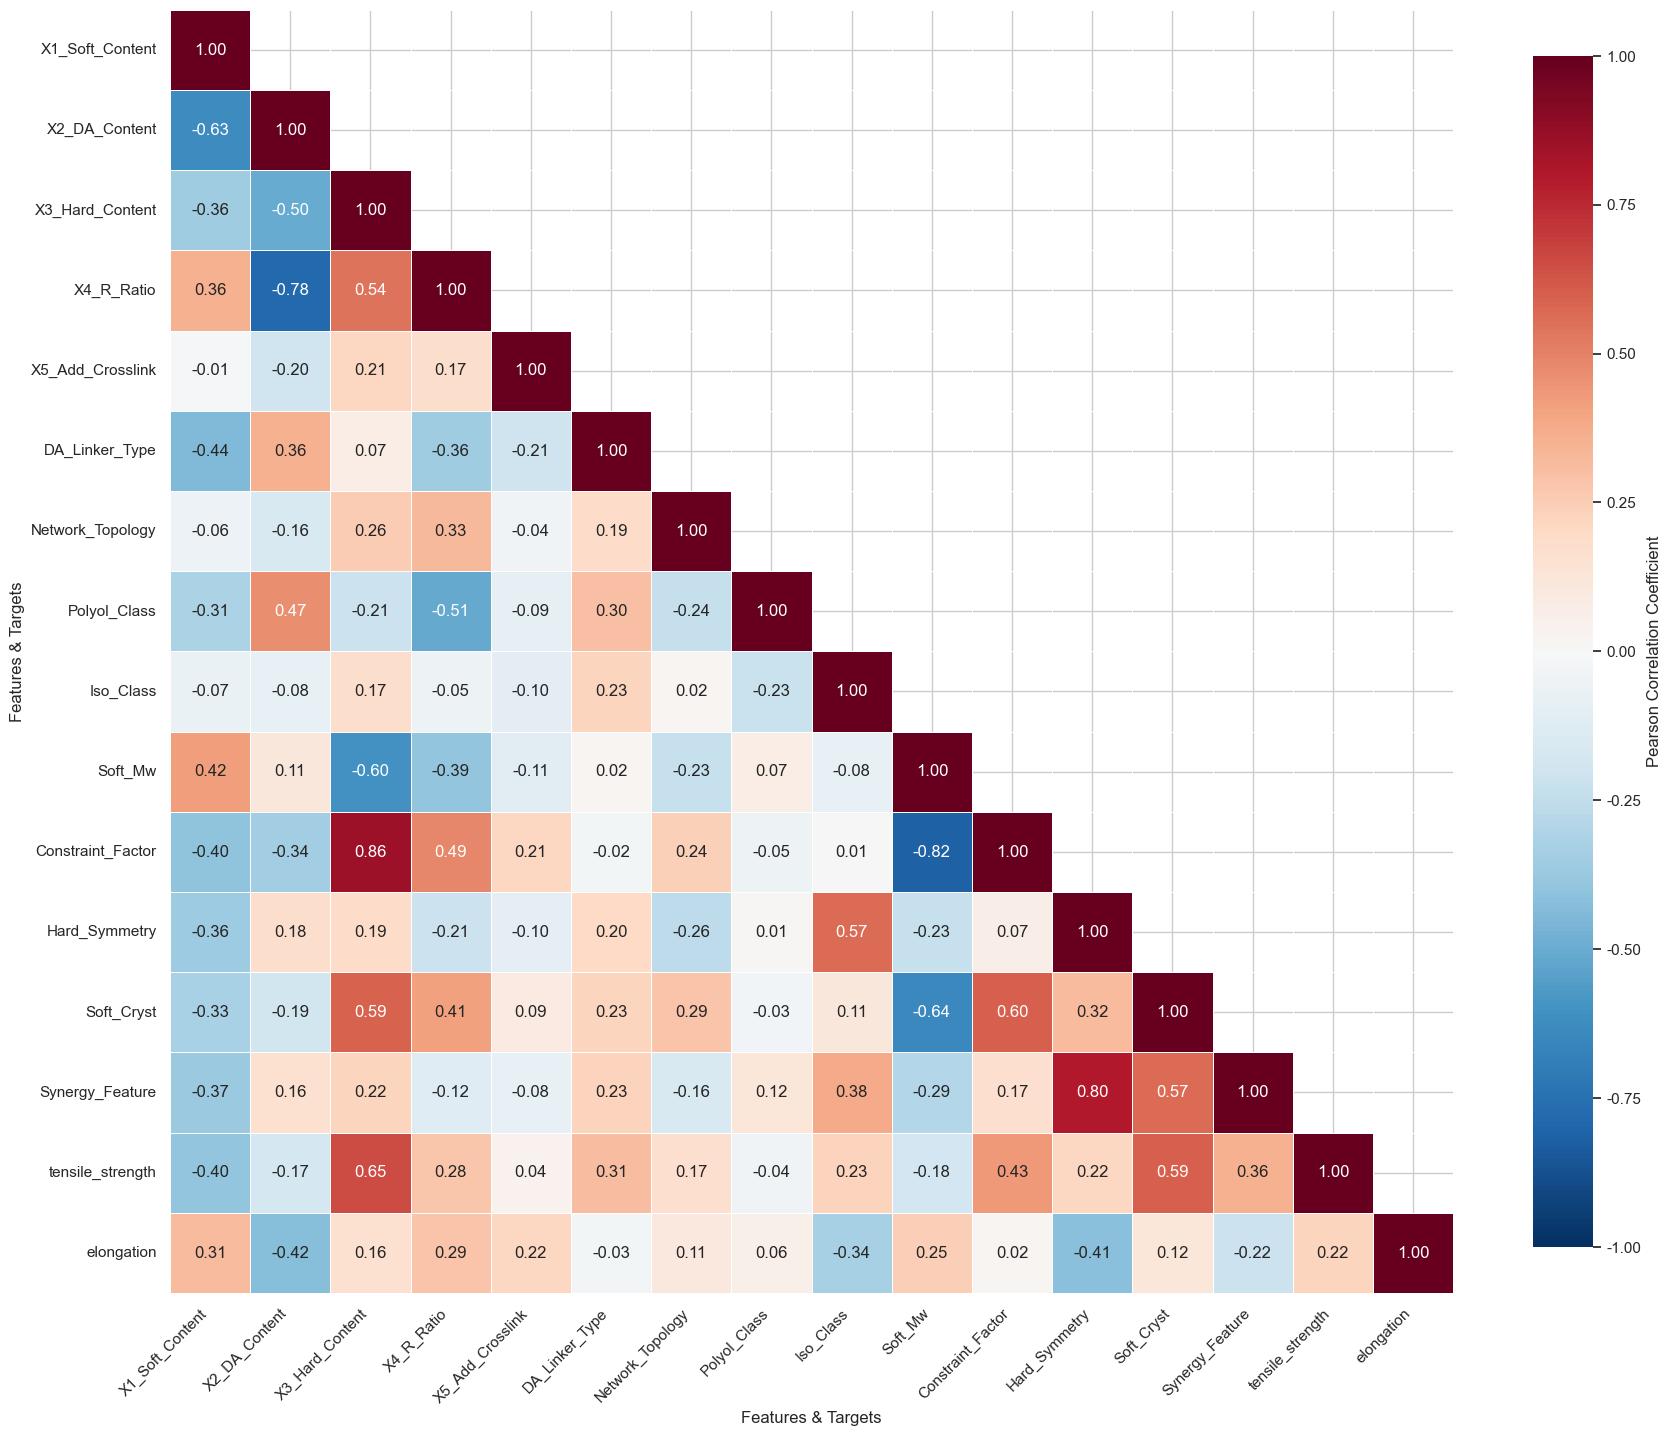

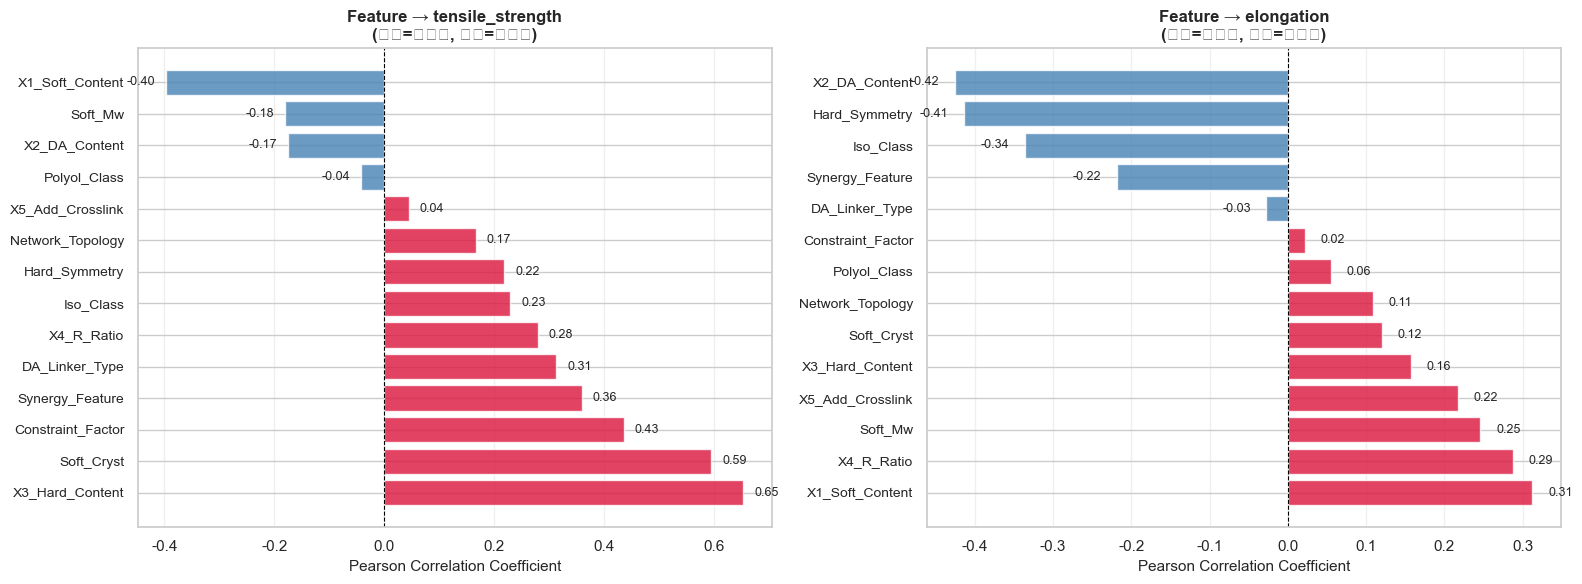


分析完成！上述发现可用于论文的 Results & Discussion 部分


In [35]:
# ============================================
# Pearson 相关性分析（证明特征设计的合理性）
# ============================================
"""
目的：
1. 证明 Trade-off 的客观存在（拉伸强度 vs 自愈合效率）
2. 证明基础特征与性能是非线性关系（线性相关系数低）
3. 检查特征冗余（多重共线性）
"""

# 准备分析数据：特征 + 三个目标性能
targets = ['tensile_strength', 'elongation', 'healing_eff']

# 对于力学性能分析，使用力学特征
# 注意：healing_eff 样本数较少，需要单独处理
print("="*80)
print("Pearson 相关性分析")
print("="*80)

# 方案1：分析力学性能的相关性（tensile_strength 和 elongation）
print("\n[方案1] 力学性能相关性分析（特征 + tensile_strength + elongation）")
print("-"*80)

# 获取有效数据（排除缺失值）
mech_targets = ['tensile_strength', 'elongation']
mech_data = df[features_mech + mech_targets].dropna()

print(f"有效样本数: {len(mech_data)}")
print(f"分析维度: {len(features_mech)} 特征 + {len(mech_targets)} 目标 = {len(features_mech) + len(mech_targets)} 维")

# 计算 Pearson 相关系数矩阵
corr_matrix_mech = mech_data.corr(method='pearson')

# 提取关键信息：两个性能之间的相关性
corr_tensile_elongation = corr_matrix_mech.loc['tensile_strength', 'elongation']
print(f"\n✅ 关键发现1: tensile_strength ↔ elongation 相关系数 = {corr_tensile_elongation:.3f}")
if corr_tensile_elongation < 0:
    print(f"   → 负相关，证明存在 Trade-off！")
else:
    print(f"   → 正相关，两者可以协同优化")

# 检查特征间的多重共线性（相关系数 > 0.9 的特征对）
print("\n✅ 关键发现2: 特征间高度相关（|r| > 0.85，可能存在冗余）")
high_corr_features = []
for i in range(len(features_mech)):
    for j in range(i+1, len(features_mech)):
        corr_val = corr_matrix_mech.loc[features_mech[i], features_mech[j]]
        if abs(corr_val) > 0.85:
            high_corr_features.append((features_mech[i], features_mech[j], corr_val))
            print(f"   {features_mech[i]} ↔ {features_mech[j]}: {corr_val:.3f}")

if not high_corr_features:
    print("   未发现高度冗余的特征对（说明特征设计良好）")

# 检查特征与性能的线性相关性（证明需要非线性模型）
print("\n✅ 关键发现3: 特征与性能的线性相关性（|r| < 0.5 说明需要非线性模型）")
for target in mech_targets:
    target_corr = corr_matrix_mech[target].drop(mech_targets).abs().sort_values(ascending=False)
    top3 = target_corr.head(3)
    print(f"\n   {target} 的 Top 3 线性相关特征:")
    for feat, corr_val in top3.items():
        print(f"      {feat}: {corr_val:.3f}")
    
    max_corr = target_corr.max()
    if max_corr < 0.5:
        print(f"   → 最强线性相关仅 {max_corr:.3f}，说明关系非线性，需要 SVR/GPR/MLP 等非线性模型！")

# 绘图1: 力学性能热力图（完整版）
fig, ax = plt.subplots(figsize=(18, 16))
mask = np.triu(np.ones_like(corr_matrix_mech, dtype=bool), k=1)  # 只显示下三角
sns.heatmap(
    corr_matrix_mech, 
    annot=True,          # 显示数值
    fmt='.2f',           # 保留2位小数
    cmap='RdBu_r',       # 红蓝配色（红=正相关，蓝=负相关）
    center=0,            # 0为中心
    vmin=-1, vmax=1,     # 相关系数范围
    mask=mask,           # 只显示下三角
    square=True,         # 正方形单元格
    linewidths=0.5,
    cbar_kws={"shrink": 0.8, "label": "Pearson Correlation Coefficient"}
)
plt.xlabel("Features & Targets", fontsize=12)
plt.ylabel("Features & Targets", fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# 绘图2: 简化版（仅特征与性能的相关性）
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for idx, target in enumerate(mech_targets):
    # 提取特征与目标的相关性
    feature_target_corr = corr_matrix_mech[target].drop(mech_targets).sort_values(ascending=False)
    
    # 绘制条形图
    colors = ['crimson' if x > 0 else 'steelblue' for x in feature_target_corr.values]
    axes[idx].barh(range(len(feature_target_corr)), feature_target_corr.values, color=colors, alpha=0.8)
    axes[idx].set_yticks(range(len(feature_target_corr)))
    axes[idx].set_yticklabels(feature_target_corr.index, fontsize=10)
    axes[idx].set_xlabel('Pearson Correlation Coefficient', fontsize=11)
    axes[idx].set_title(f'Feature → {target}\n(红色=正相关, 蓝色=负相关)', fontsize=12, fontweight='bold')
    axes[idx].axvline(x=0, color='black', linewidth=0.8, linestyle='--')
    axes[idx].grid(axis='x', alpha=0.3)
    
    # 添加数值标签
    for i, v in enumerate(feature_target_corr.values):
        axes[idx].text(v + 0.02 if v > 0 else v - 0.02, i, f'{v:.2f}', 
                       va='center', ha='left' if v > 0 else 'right', fontsize=9)

plt.tight_layout()
plt.show()

print("\n" + "="*80)
print("分析完成！上述发现可用于论文的 Results & Discussion 部分")
print("="*80)


[方案2] 三目标性能间的 Trade-off 分析
三目标都有数据的样本数: 37
（healing_eff 数据较少，仅 37 个样本）

三目标性能之间的 Pearson 相关系数：
                  tensile_strength  elongation  healing_eff
tensile_strength          1.000000    0.381294     0.576129
elongation                0.381294    1.000000     0.152781
healing_eff               0.576129    0.152781     1.000000

🔍 Trade-off 证明
tensile_strength ↔ healing_eff: 0.576
   ❌ 正相关，不存在 Trade-off

elongation ↔ healing_eff: 0.153
   ❌ 正相关，不存在 Trade-off


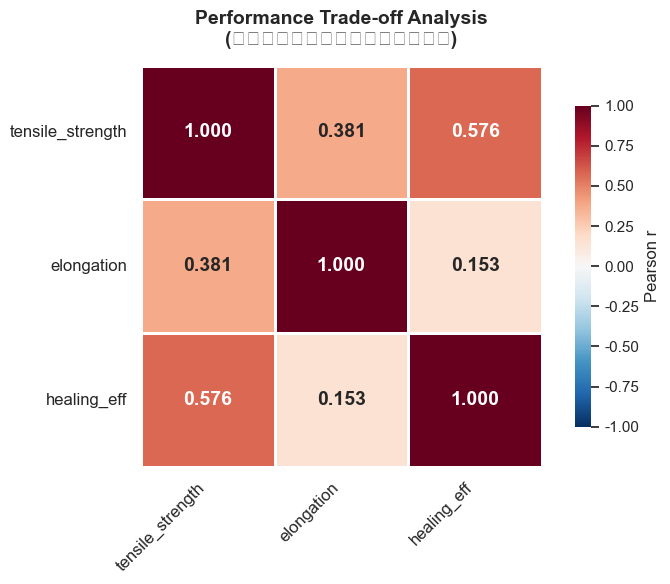

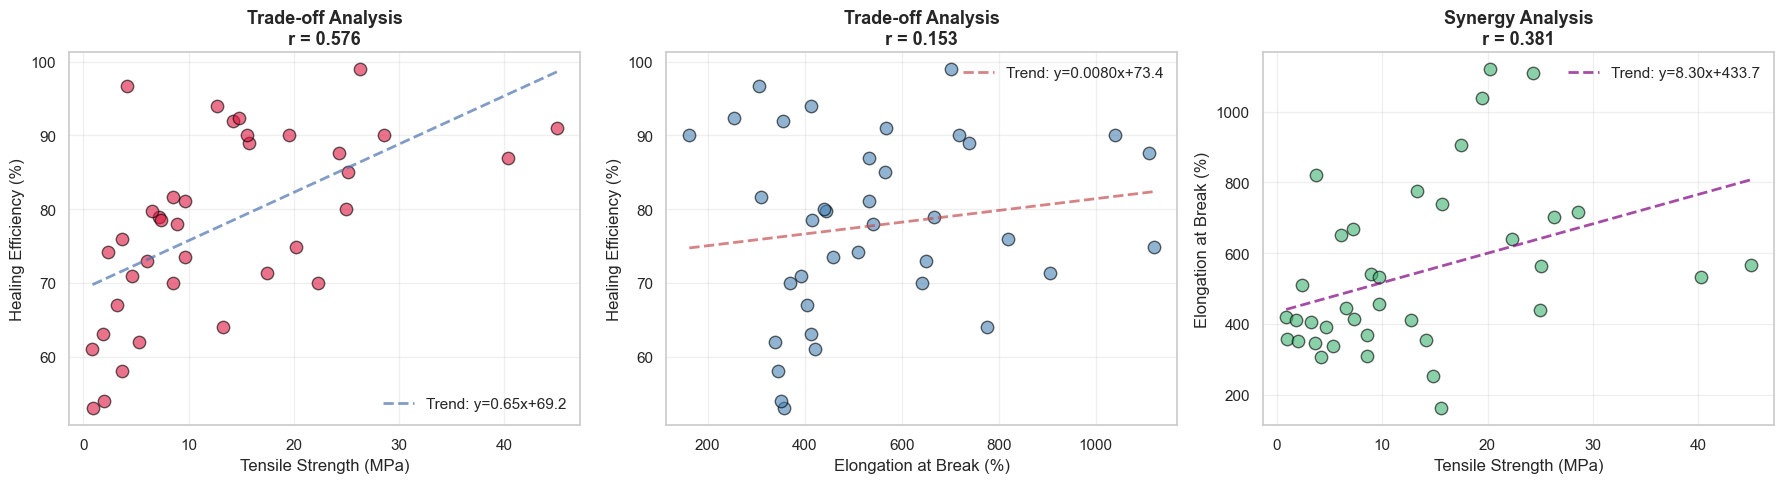


✅ Trade-off 分析完成！可用于论文 Introduction 或 Results 部分


In [33]:
# ============================================
# [方案2] 三目标性能相关性分析（证明 Trade-off）
# ============================================
"""
注意：healing_eff 样本数较少（37个），需要单独分析
分析目标：证明 tensile_strength 与 healing_eff 之间的负相关（Trade-off）
"""
print("\n" + "="*80)
print("[方案2] 三目标性能间的 Trade-off 分析")
print("="*80)

# 获取三个目标的有效数据（只保留三个目标都有值的样本）
all_targets = ['tensile_strength', 'elongation', 'healing_eff']
target_data = df[all_targets].dropna()

print(f"三目标都有数据的样本数: {len(target_data)}")
print(f"（healing_eff 数据较少，仅 {len(df['healing_eff'].dropna())} 个样本）\n")

# 计算三目标之间的相关性
corr_targets = target_data.corr(method='pearson')

print("三目标性能之间的 Pearson 相关系数：")
print(corr_targets)
print()

# 关键发现：证明 Trade-off
corr_tensile_healing = corr_targets.loc['tensile_strength', 'healing_eff']
corr_elongation_healing = corr_targets.loc['elongation', 'healing_eff']

print("="*80)
print("🔍 Trade-off 证明")
print("="*80)
print(f"tensile_strength ↔ healing_eff: {corr_tensile_healing:.3f}")
if corr_tensile_healing < -0.3:
    print("   ✅ 显著负相关！证明存在 Trade-off：提高拉伸强度会降低自愈合效率")
elif corr_tensile_healing < 0:
    print("   ⚠️ 弱负相关，Trade-off 趋势存在但不显著")
else:
    print("   ❌ 正相关，不存在 Trade-off")

print(f"\nelongation ↔ healing_eff: {corr_elongation_healing:.3f}")
if corr_elongation_healing < -0.3:
    print("   ✅ 显著负相关！证明存在 Trade-off：提高断裂伸长率会降低自愈合效率")
elif corr_elongation_healing < 0:
    print("   ⚠️ 弱负相关，Trade-off 趋势存在但不显著")
else:
    print("   ❌ 正相关，不存在 Trade-off")

# 绘图：三目标相关性热力图
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(
    corr_targets,
    annot=True,
    fmt='.3f',
    cmap='RdBu_r',
    center=0,
    vmin=-1, vmax=1,
    square=True,
    linewidths=2,
    cbar_kws={"shrink": 0.8, "label": "Pearson r"},
    annot_kws={"fontsize": 14, "fontweight": "bold"}
)
plt.title("Performance Trade-off Analysis\n(证明拉伸强度与自愈合效率的矛盾)", 
          fontsize=14, fontweight='bold', pad=15)
plt.xticks(fontsize=12, rotation=45, ha='right')
plt.yticks(fontsize=12, rotation=0)
plt.tight_layout()
plt.show()

# 散点图矩阵：直观展示 Trade-off
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 散点图1: tensile_strength vs healing_eff
axes[0].scatter(target_data['tensile_strength'], target_data['healing_eff'], 
                alpha=0.6, s=80, c='crimson', edgecolors='black')
axes[0].set_xlabel('Tensile Strength (MPa)', fontsize=12)
axes[0].set_ylabel('Healing Efficiency (%)', fontsize=12)
axes[0].set_title(f'Trade-off Analysis\nr = {corr_tensile_healing:.3f}', fontsize=13, fontweight='bold')
axes[0].grid(alpha=0.3)
# 添加趋势线
z = np.polyfit(target_data['tensile_strength'], target_data['healing_eff'], 1)
p = np.poly1d(z)
x_line = np.linspace(target_data['tensile_strength'].min(), target_data['tensile_strength'].max(), 100)
axes[0].plot(x_line, p(x_line), "b--", linewidth=2, alpha=0.7, label=f'Trend: y={z[0]:.2f}x+{z[1]:.1f}')
axes[0].legend()

# 散点图2: elongation vs healing_eff
axes[1].scatter(target_data['elongation'], target_data['healing_eff'], 
                alpha=0.6, s=80, c='steelblue', edgecolors='black')
axes[1].set_xlabel('Elongation at Break (%)', fontsize=12)
axes[1].set_ylabel('Healing Efficiency (%)', fontsize=12)
axes[1].set_title(f'Trade-off Analysis\nr = {corr_elongation_healing:.3f}', fontsize=13, fontweight='bold')
axes[1].grid(alpha=0.3)
z2 = np.polyfit(target_data['elongation'], target_data['healing_eff'], 1)
p2 = np.poly1d(z2)
x_line2 = np.linspace(target_data['elongation'].min(), target_data['elongation'].max(), 100)
axes[1].plot(x_line2, p2(x_line2), "r--", linewidth=2, alpha=0.7, label=f'Trend: y={z2[0]:.4f}x+{z2[1]:.1f}')
axes[1].legend()

# 散点图3: tensile_strength vs elongation
corr_t_e = corr_targets.loc['tensile_strength', 'elongation']
axes[2].scatter(target_data['tensile_strength'], target_data['elongation'], 
                alpha=0.6, s=80, c='mediumseagreen', edgecolors='black')
axes[2].set_xlabel('Tensile Strength (MPa)', fontsize=12)
axes[2].set_ylabel('Elongation at Break (%)', fontsize=12)
axes[2].set_title(f'Synergy Analysis\nr = {corr_t_e:.3f}', fontsize=13, fontweight='bold')
axes[2].grid(alpha=0.3)
z3 = np.polyfit(target_data['tensile_strength'], target_data['elongation'], 1)
p3 = np.poly1d(z3)
x_line3 = np.linspace(target_data['tensile_strength'].min(), target_data['tensile_strength'].max(), 100)
axes[2].plot(x_line3, p3(x_line3), "purple", linestyle='--', linewidth=2, alpha=0.7, 
             label=f'Trend: y={z3[0]:.2f}x+{z3[1]:.1f}')
axes[2].legend()

plt.tight_layout()
plt.show()

print("\n" + "="*80)
print("✅ Trade-off 分析完成！可用于论文 Introduction 或 Results 部分")
print("="*80)

In [ ]:
# 1. 确定原本的数据集
original_df = df.copy()

# 2. 确定你目前使用的特征列表
# (确保这里的 features_mech 是你实际传入模型的列表)
features_to_check = features_mech

# 3. 检查缺失情况
print(f"原始数据行数: {len(original_df)}")

# 筛选出含有 NaN 的行（即被删除的行）
dropped_rows = original_df[original_df[features_to_check].isna().any(axis=1)]

print(f"被删除的数据行数: {len(dropped_rows)}")
print("-" * 30)

if len(dropped_rows) > 0:
    print("以下样本因存在缺失值而被剔除：")
    # 显示 sample_id 和 具体缺失的列
    # 假设你有一列叫 'sample_id'，如果没有请删掉 'sample_id'
    cols_to_show = ['sample_id'] + features_to_check
    
    # 仅展示确实有缺失值的列，方便查看
    for index, row in dropped_rows.iterrows():
        missing_cols = [col for col in features_to_check if pd.isna(row[col])]
        sample_id = row.get('sample_id', f'Row_{index}')
        print(f"样本 ID: {sample_id} -> 缺失字段: {missing_cols}")

Fitting 84 folds for each of 108 candidates, totalling 9072 fits

[最佳参数组合]
{'svr__C': 10, 'svr__epsilon': 0.1, 'svr__gamma': 'scale'}

正在生成最终预测结果...

=== SVR (调优后) 结果 ===
R2 Score: 0.7407
RMSE: 6.8479


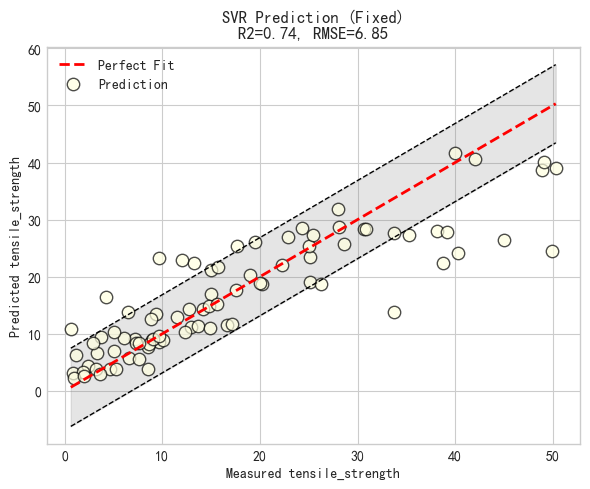

In [ ]:
# SVR
target_col = 'tensile_strength'  
features = features_mech
X, y = get_clean_data(target_col, features, df)

# --- 2. 定义参数网格 ---
# SVR 的三个核心参数：
# C: 惩罚系数。越大越不容忍误差（容易过拟合），越小越平滑（容易欠拟合）。
# gamma: 核函数宽度。越大越关注局部细节，越小越关注全局趋势。
# epsilon: 对误差的容忍带宽度。
param_grid = {
    'svr__C': [1, 10, 50, 100, 500, 1000], 
    'svr__gamma': ['scale', 0.001, 0.01, 0.1, 0.5, 1.0],
    'svr__epsilon': [0.01, 0.1, 0.5]
}

# --- 3. 网格搜索 (GridSearchCV) ---
# 建立 Pipeline
pipe = make_pipeline(StandardScaler(), SVR(kernel='rbf'))

# 使用 LOOCV 进行搜索 (保证和小样本验证逻辑一致)
# scoring='neg_mean_squared_error' 表示寻找 MSE 最小的组合
grid_search = GridSearchCV(
    pipe, 
    param_grid, 
    cv=LeaveOneOut(), # 如果觉得太慢，可以改为 cv=5
    scoring='neg_mean_squared_error',
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X, y)

# 获取最佳模型
best_svr = grid_search.best_estimator_
best_params = grid_search.best_params_

print("\n[最佳参数组合]")
print(best_params)

# --- 4. 使用最佳参数进行最终预测 (LOOCV) ---
# 为了严谨，我们用在这个最佳参数下重新跑一遍 LOOCV 预测
print("\n正在生成最终预测结果...")
y_pred_svr = cross_val_predict(best_svr, X, y, cv=LeaveOneOut(), n_jobs=-1)

# 计算指标
r2 = r2_score(y, y_pred_svr)
rmse = np.sqrt(mean_squared_error(y, y_pred_svr))

print(f"\n=== SVR (调优后) 结果 ===")
print(f"R2 Score: {r2:.4f}")
print(f"RMSE: {rmse:.4f}")

# --- 5. 绘图: 预测值 vs 真实值 ---
# 绘图
plt.figure(figsize=(6, 5))
## parity轴
min_val = min(y.min(), y_pred_svr.min())
max_val = max(y.max(), y_pred_svr.max())
x_line = np.linspace(min_val, max_val, 200)

## 误差区域
plt.fill_between(x_line,x_line - rmse,x_line + rmse,color='gray',alpha=0.2)

## 拟合直线
min_val, max_val = min(y.min(), y_pred_svr.min()), max(y.max(), y_pred_svr.max())
plt.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, label='Perfect Fit')

## 误差线
plt.plot(x_line, x_line + rmse, 'k--', linewidth=1)
plt.plot(x_line, x_line - rmse, 'k--', linewidth=1)

# 散点图
plt.scatter(y, y_pred_svr, alpha=0.7, c='lightyellow', edgecolors='k', label='Prediction',s=80)

plt.xlabel(f'Measured {target_col}')
plt.ylabel(f'Predicted {target_col}')
plt.title(f'SVR Prediction (Fixed)\nR2={r2:.2f}, RMSE={rmse:.2f}')
plt.legend()
plt.tight_layout()
plt.show()


正在计算排列重要性 (Permutation Importance)...

[特征重要性排行 (基于 R2 损失)]
(数值代表：如果没有这个特征，R2 会下降多少)
1. X3_Hard_Content: 0.1263
2. healing_temperature: 0.1146
3. Soft_Cryst: 0.1110
4. X1_Soft_Content: 0.1017
5. DA_Linker_Type: 0.0891
6. Iso_Class: 0.0730
7. Synergy_Feature: 0.0703
8. Constraint_Factor: 0.0695
9. Soft_Mw: 0.0513
10. Network_Topology: 0.0402
11. X2_DA_Content: 0.0363
12. Polyol_Class: 0.0346
13. X4_R_Ratio: 0.0338
14. Hard_Symmetry: 0.0316
15. healing_time: 0.0282
16. Extender_Class: 0.0127
17. X5_Add_Crosslink: 0.0127
18. Add_Crosslinker_Flag: 0.0127

正在计算 SVR 的 SHAP 特征重要性 (内置进度条)...


  0%|          | 0/84 [00:00<?, ?it/s]


[SHAP 特征重要性排行 (基于平均绝对贡献)]
1. Soft_Cryst: 1.8824
2. X3_Hard_Content: 1.7767
3. healing_temperature: 1.7047
4. X1_Soft_Content: 1.5837
5. DA_Linker_Type: 1.3514
6. Synergy_Feature: 1.1912
7. Constraint_Factor: 0.8169
8. Soft_Mw: 0.8138
9. Iso_Class: 0.7815
10. Polyol_Class: 0.3237
11. Network_Topology: 0.2950
12. X4_R_Ratio: 0.2300
13. healing_time: 0.2144
14. X2_DA_Content: 0.1986
15. Hard_Symmetry: 0.1414
16. Add_Crosslinker_Flag: 0.0109
17. X5_Add_Crosslink: 0.0105
18. Extender_Class: 0.0088


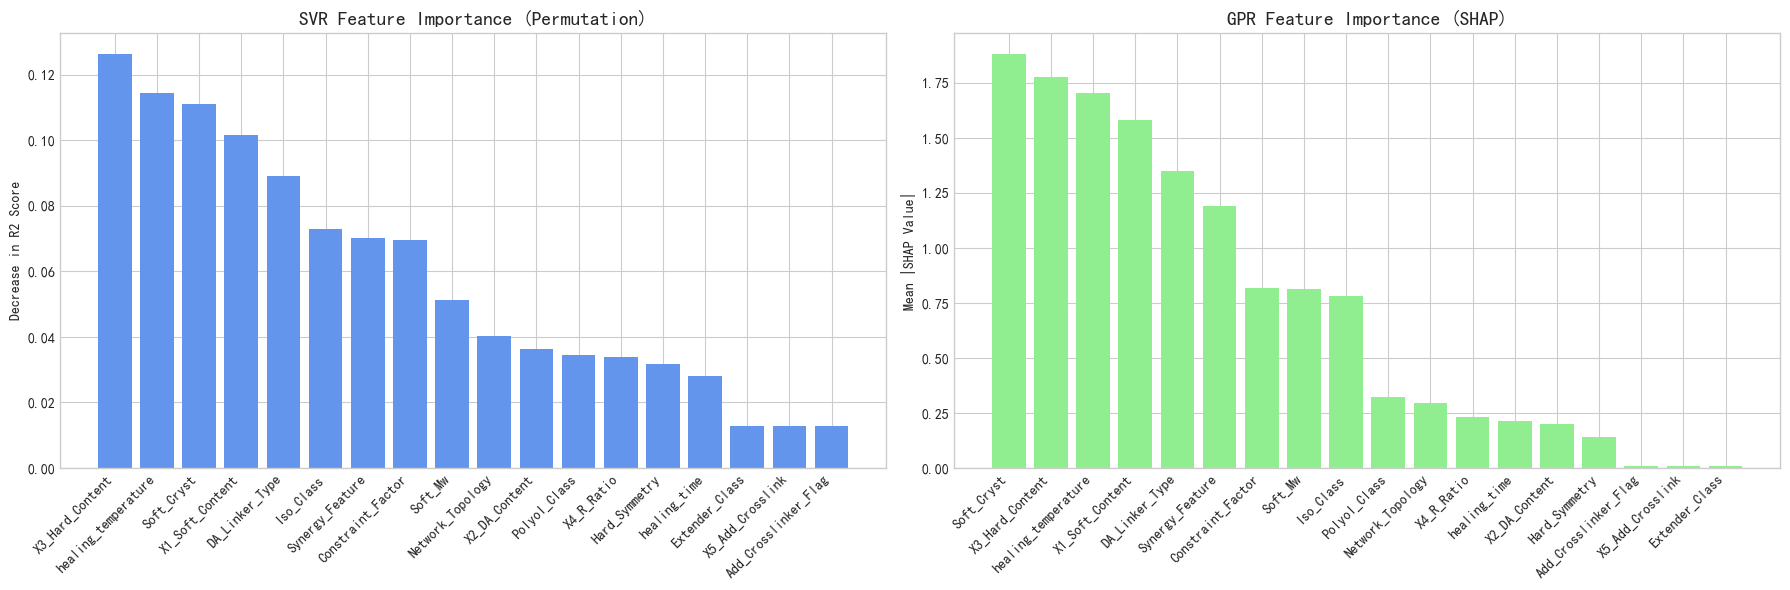

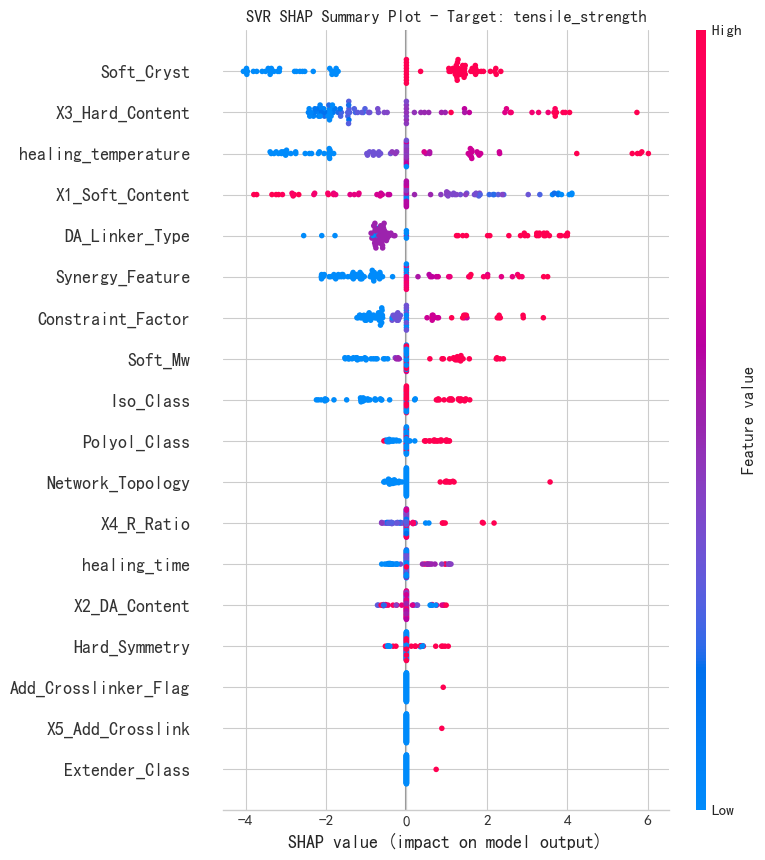

In [27]:
# SVR + SHAP 特征重要性分析 (增强版)
# 全量拟合一次模型
best_svr.fit(X, y)

print("\n正在计算排列重要性 (Permutation Importance)...")
# n_repeats、random_state参数设置保证结果可复现
r = permutation_importance(best_svr, X, y, n_repeats=30, random_state=42, scoring='r2')

# 获取重要性均值
importances = r.importances_mean
# 排序
indices = np.argsort(importances)[::-1]

print("\n[特征重要性排行 (基于 R2 损失)]")
print("(数值代表：如果没有这个特征，R2 会下降多少)")
top_features_perm = []
for i in range(len(features)):
    idx = indices[i]
    # 只显示正贡献的特征
    if importances[idx] > 0:
        print(f"{i+1}. {features[idx]}: {importances[idx]:.4f}")
        top_features_perm.append((features[idx], importances[idx]))

print("\n正在计算 SVR 的 SHAP 特征重要性 (内置进度条)...")

# SHAP 分析

# 背景数据集摘要 (加速KernelExplainer)
X_train_summary = shap.kmeans(X, k=30).data  

# KernelExplainer for SVR
explainer = shap.KernelExplainer(best_svr.predict, X_train_summary)

# 计算SHAP值 (自动显示tqdm进度条)
shap_values = explainer.shap_values(X, nsamples=2000)  # 调整nsamples平衡速度/精度

# 全局重要性：平均绝对SHAP值
shap_importances = np.abs(shap_values).mean(axis=0)
shap_indices = np.argsort(shap_importances)[::-1]

print("\n[SHAP 特征重要性排行 (基于平均绝对贡献)]")
top_features_shap = []
for i in range(len(features)):
    idx = shap_indices[i]
    print(f"{i+1}. {features[idx]}: {shap_importances[idx]:.4f}")
    top_features_shap.append((features[idx], shap_importances[idx]))

# --- 对比特征图绘制 ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 6))

# Permutation图
ax1.bar(range(len(top_features_perm)), [val for name, val in top_features_perm], 
        color='cornflowerblue', align="center")
ax1.set_title("SVR Feature Importance (Permutation)", fontsize=14)
ax1.set_xticks(range(len(top_features_perm)))
ax1.set_xticklabels([name for name, val in top_features_perm], rotation=45, ha='right')
ax1.set_ylabel("Decrease in R2 Score")

# SHAP图
ax2.bar(range(len(top_features_shap)), [val for name, val in top_features_shap], 
        color='lightgreen', align="center")
ax2.set_title("GPR Feature Importance (SHAP)", fontsize=14)
ax2.set_xticks(range(len(top_features_shap)))
ax2.set_xticklabels([name for name, val in top_features_shap], rotation=45, ha='right')
ax2.set_ylabel("Mean |SHAP Value|")

plt.tight_layout()
plt.show()

# SHAP Summary Plot (beeswarm图，推荐查看交互效应)
shap.summary_plot(shap_values, X, feature_names=features, show=False)
plt.title(f"SVR SHAP Summary Plot - Target: {target_col}")
plt.tight_layout()
plt.show()

开始进行GPR模型运算 (样本数: 84)...
=== GPR结果 (tensile_strength) ===
R2 Score: 0.6785
RMSE: 7.6245


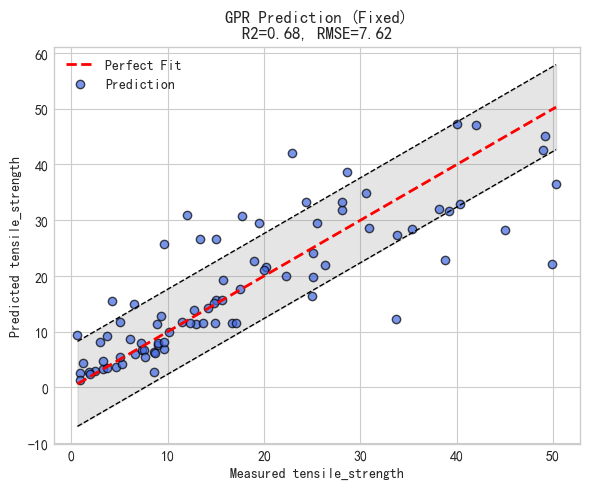

In [24]:
# GPR
from sklearn.compose import TransformedTargetRegressor

target_col = 'tensile_strength'
features = features_mech
X, y = get_clean_data(target_col, features, df)

print(f"开始进行GPR模型运算 (样本数: {len(y)})...")

# 定义核函数
kernel = C(1.0, (1e-5, 1e5)) * \
         Matern(length_scale=1.0, length_scale_bounds=(1e-3, 1e4), nu=2.5) + \
         WhiteKernel(noise_level=0.1, noise_level_bounds=(1e-5, 1e1))

#  定义模型 
gpr_model = make_pipeline(
    StandardScaler(),  # 标准化特征 X
    GaussianProcessRegressor(
        kernel=kernel,
        n_restarts_optimizer=10,  # 重启10次防止局部最优
        random_state=42,
        normalize_y=True       
    )
)

# 模型性能评估
r2, rmse, y_pred_gpr = evaluate_model(gpr_model, X, y, task_name="GPR")

print(f"=== GPR结果 ({target_col}) ===")
print(f"R2 Score: {r2:.4f}")
print(f"RMSE: {rmse:.4f}")

# 绘图
plt.figure(figsize=(6, 5))
## parity轴
min_val = min(y.min(), y_pred_gpr.min())
max_val = max(y.max(), y_pred_gpr.max())
x_line = np.linspace(min_val, max_val, 200)

## 误差区域
plt.fill_between(x_line,x_line - rmse,x_line + rmse,color='gray',alpha=0.2)

## 拟合直线
min_val, max_val = min(y.min(), y_pred_gpr.min()), max(y.max(), y_pred_gpr.max())
plt.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, label='Perfect Fit')

## 误差线
plt.plot(x_line, x_line + rmse, 'k--', linewidth=1)
plt.plot(x_line, x_line - rmse, 'k--', linewidth=1)

# 散点图
plt.scatter(y, y_pred_gpr, alpha=0.7, c='royalblue', edgecolors='k', label='Prediction')

plt.xlabel(f'Measured {target_col}')
plt.ylabel(f'Predicted {target_col}')
plt.title(f'GPR Prediction (Fixed)\nR2={r2:.2f}, RMSE={rmse:.2f}')
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
# GPR + SHAP 特征重要性分析 (增强版)
# 全量拟合一次模型
gpr_model.fit(X, y)

print("\n正在计算排列重要性 (Permutation Importance)...")
# n_repeats、random_state参数设置保证结果可复现
r = permutation_importance(gpr_model, X, y, n_repeats=30, random_state=42, scoring='r2')

# 获取重要性均值
importances = r.importances_mean
# 排序
indices = np.argsort(importances)[::-1]

print("\n[特征重要性排行 (基于 R2 损失)]")
print("(数值代表：如果没有这个特征，R2 会下降多少)")
top_features_perm = []
for i in range(len(features)):
    idx = indices[i]
    # 只显示正贡献的特征
    if importances[idx] > 0:
        print(f"{i+1}. {features[idx]}: {importances[idx]:.4f}")
        top_features_perm.append((features[idx], importances[idx]))

print("\n正在计算 GPR 的 SHAP 特征重要性 (内置进度条)...")

# SHAP 分析

# 背景数据集摘要 (加速KernelExplainer)
X_train_summary = shap.kmeans(X, k=30).data  

# KernelExplainer for GPR
explainer = shap.KernelExplainer(gpr_model.predict, X_train_summary)

# 计算SHAP值 (自动显示tqdm进度条)
shap_values = explainer.shap_values(X, nsamples=2000)  # 调整nsamples平衡速度/精度

# 全局重要性：平均绝对SHAP值
shap_importances = np.abs(shap_values).mean(axis=0)
shap_indices = np.argsort(shap_importances)[::-1]

print("\n[SHAP 特征重要性排行 (基于平均绝对贡献)]")
top_features_shap = []
for i in range(len(features)):
    idx = shap_indices[i]
    print(f"{i+1}. {features[idx]}: {shap_importances[idx]:.4f}")
    top_features_shap.append((features[idx], shap_importances[idx]))

# --- 对比特征图绘制 ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 6))

# Permutation图
ax1.bar(range(len(top_features_perm)), [val for name, val in top_features_perm], 
        color='cornflowerblue', align="center")
ax1.set_title("GPR Feature Importance (Permutation)", fontsize=14)
ax1.set_xticks(range(len(top_features_perm)))
ax1.set_xticklabels([name for name, val in top_features_perm], rotation=45, ha='right')
ax1.set_ylabel("Decrease in R2 Score")

# SHAP图
ax2.bar(range(len(top_features_shap)), [val for name, val in top_features_shap], 
        color='lightgreen', align="center")
ax2.set_title("GPR Feature Importance (SHAP)", fontsize=14)
ax2.set_xticks(range(len(top_features_shap)))
ax2.set_xticklabels([name for name, val in top_features_shap], rotation=45, ha='right')
ax2.set_ylabel("Mean |SHAP Value|")

plt.tight_layout()
plt.show()

# SHAP Summary Plot (beeswarm图，推荐查看交互效应)
shap.summary_plot(shap_values, X, feature_names=features, show=False)
plt.title(f"GPR SHAP Summary Plot - Target: {target_col}")
plt.tight_layout()
plt.show()


In [ ]:
# Random Forest
target_col = 'tensile_strength'  
features = features_mech          
X, y = get_clean_data(target_col, features, df)

# 获取数据
X, y = get_clean_data(target_col, features, df)

# 定义模型
rf_model = RandomForestRegressor(
    n_estimators=350,      # 树的数量
    max_depth=10,        # 树的最大深度
    min_samples_split=5,   # 节点分裂所需的最小样本数
    random_state=42,
    n_jobs=-1
)

# 评估
print("正在进行 LOOCV 交叉验证评估精度...")
y_pred = cross_val_predict(rf_model, X, y, cv=LeaveOneOut(), n_jobs=-1)
r2 = r2_score(y, y_pred)
rmse = np.sqrt(mean_squared_error(y, y_pred))

print(f"=== Random Forest 结果 ({target_col}) ===")
print(f"R2 Score: {r2:.4f}")
print(f"RMSE: {rmse:.4f}")

# 全量拟合一次模型
print("\n正在全量拟合模型 (为 SHAP 做准备)...")
rf_model.fit(X, y)

# 绘图
plt.figure(figsize=(5, 5))
plt.scatter(y, y_pred, color='teal', alpha=0.6)
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--')
plt.title(f"RF Prediction (R2={r2:.2f})")
plt.xlabel("True Value")
plt.ylabel("Predicted Value")
plt.show()

In [ ]:
# Random Forest
# --- SHAP 分析 ---
# 对于随机森林，SHAP 计算量比 XGBoost 大
print("正在计算 Random Forest 的 SHAP 值...")
explainer = shap.TreeExplainer(rf_model)
# 如果报错，尝试: shap_values = explainer.shap_values(X)
shap_values = explainer(X)

# 绘图
plt.figure(figsize=(10, 6))
plt.title(f"RF - SHAP Summary for {target_col}")
# 处理 shap_values 格式兼容性 
if isinstance(shap_values, list): # 针对分类任务或旧版
    sv = shap_values[1]
else:
    sv = shap_values

shap.summary_plot(sv, X, feature_names=features)

In [ ]:
# XGBoost
target_col = 'healing_eff' 
features = features_mech
X, y = get_clean_data(target_col, features, df)

# --- 2. 定义参数字典 (注意：这里是字典 dict，不是模型对象) ---
xgb_params = {
    'n_estimators': 100,
    'learning_rate': 0.02,
    'max_depth': 5,
    'subsample': 0.7,
    'colsample_bytree': 0.8,
    'random_state': 42,
    'n_jobs': -1
    # 'device': 'cuda' # 如果有显卡，取消注释这一行
}

# --- 3. 手写 LOOCV 循环 (同时收集 预测值 和 SHAP值) ---
print(f"正在进行严谨的 CV-SHAP 计算 (样本数: {len(y)})...")

loo = LeaveOneOut()
y_pred_cv = np.zeros(len(y)) # 存放预测结果
shap_values_cv = []          # 存放 SHAP 结果
indices_cv = []              # 记录顺序，防止乱序

# 遍历每一个样本
for train_idx, test_idx in loo.split(X):
    # A. 切分数据
    X_train, X_test = X[train_idx], X[test_idx]
    y_train, y_test = y[train_idx], y[test_idx]
    
    # B. 训练模型 (只用训练集!)
    model = XGBRegressor(**xgb_params)
    model.fit(X_train, y_train)
    
    # C. 预测 (为了算 R2)
    pred = model.predict(X_test)
    y_pred_cv[test_idx] = pred
    
    # D. 计算 SHAP (为了解释)
    # 注意：我们要解释的是模型对“测试集”的判断逻辑
    explainer = shap.TreeExplainer(model)
    shap_val = explainer.shap_values(X_test)
    
    # E. 收集结果
    shap_values_cv.append(shap_val[0]) # LOOCV每次只有1个样本
    indices_cv.append(test_idx[0])

# 将 SHAP list 转为矩阵
shap_values_cv = np.array(shap_values_cv)

# --- 4. 结果汇总 ---
# 真实的 R2 (基于 LOOCV)
r2_real = r2_score(y, y_pred_cv)
rmse_real = np.sqrt(mean_squared_error(y, y_pred_cv))

print(f"\n=== 最终结果 (基于 LOOCV) ===")
print(f"✅ 真实泛化 R2: {r2_real:.4f}")
print(f"✅ 真实泛化 RMSE: {rmse_real:.4f}")

# 绘图
plt.figure(figsize=(6, 5))
plt.scatter(y, y_pred_cv, color='purple', alpha=0.6, label='CV Prediction')
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--', label='Perfect Fit')
plt.title(f"Real XGBoost Performance\nR2={r2_real:.2f}")
plt.xlabel("Measured")
plt.ylabel("Predicted")
plt.legend()
plt.show()

In [ ]:

# --- 5. 真实的 SHAP 绘图 ---
print("\n生成 CV-SHAP 图 (解释的是模型如何预测未知样本)...")

# 图1: 蜜蜂图
plt.figure(figsize=(10, 6))
plt.title(f"CV-SHAP Summary (Generalization Logic)", fontsize=16)
shap.summary_plot(shap_values_cv, X, feature_names=features, show=False)
plt.tight_layout()
plt.show()

# 图2: 依赖图 (看新特征)
if 'Iso_Type' in features:
    shap.dependence_plot('Iso_Type', shap_values_cv, X, feature_names=features, interaction_index=None)

Fitting 84 folds for each of 42 candidates, totalling 3528 fits

[最佳参数组合]
{'kernelridge__alpha': 0.05, 'kernelridge__gamma': 0.01}

正在生成最终预测结果...

=== KRR (调优后) 结果 ===
R2 Score: 0.7337
RMSE: 6.9392


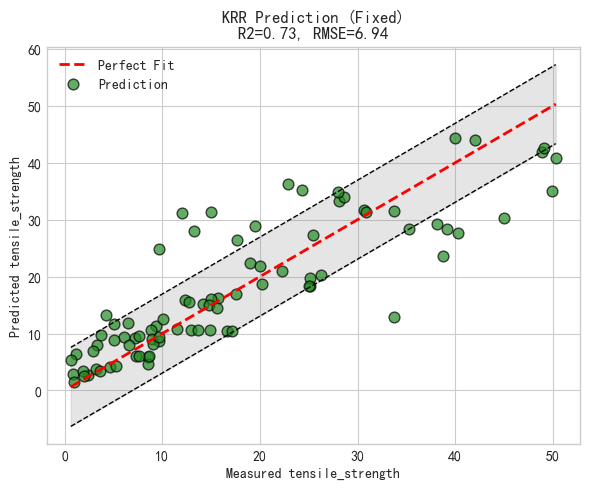

In [20]:
# KRR
target_col = 'tensile_strength'
features = features_mech
X, y = get_clean_data(target_col, features, df)

# --- 2. 定义参数网格 ---
# alpha: 正则化项。类似于 SVR 的 1/C。
# gamma: RBF 核的宽度。
param_grid = {
    'kernelridge__alpha': [1e-3, 1e-2, 0.04, 0.05, 0.1, 1, 10],   # 正则化强度
    'kernelridge__gamma': [1e-3, 1e-2, 0.1, 0.5, 1, 5] # 核函数敏感度
}

# --- 3. 网格搜索 (GridSearchCV) ---
pipe = make_pipeline(StandardScaler(), KernelRidge(kernel='rbf'))

grid_search = GridSearchCV(
    pipe, 
    param_grid, 
    cv=LeaveOneOut(), # 保持一致，使用留一法
    scoring='neg_mean_squared_error',
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X, y)

# 获取最佳模型
best_krr = grid_search.best_estimator_
best_params = grid_search.best_params_

print("\n[最佳参数组合]")
print(best_params)

# --- 4. 使用最佳参数进行最终预测 (LOOCV) ---
# 再次跑一遍 LOOCV 以获取真实的泛化分数
print("\n正在生成最终预测结果...")
y_pred_krr = cross_val_predict(best_krr, X, y, cv=LeaveOneOut(), n_jobs=-1)

# 计算指标
r2 = r2_score(y, y_pred_krr)
rmse = np.sqrt(mean_squared_error(y, y_pred_krr))

print(f"\n=== KRR (调优后) 结果 ===")
print(f"R2 Score: {r2:.4f}")
print(f"RMSE: {rmse:.4f}")

# --- 5. 绘图: 预测值 vs 真实值 ---


# 绘图
plt.figure(figsize=(6, 5))
## parity轴
min_val = min(y.min(), y_pred_krr.min())
max_val = max(y.max(), y_pred_krr.max())
x_line = np.linspace(min_val, max_val, 200)

## 误差区域
plt.fill_between(x_line,x_line - rmse,x_line + rmse,color='gray',alpha=0.2)

## 拟合直线
min_val, max_val = min(y.min(), y_pred_krr.min()), max(y.max(), y_pred_krr.max())
plt.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, label='Perfect Fit')

## 误差线
plt.plot(x_line, x_line + rmse, 'k--', linewidth=1)
plt.plot(x_line, x_line - rmse, 'k--', linewidth=1)

# 散点图
plt.scatter(y, y_pred_krr, alpha=0.7, c='forestgreen', edgecolors='k', label='Prediction',s=60)

plt.xlabel(f'Measured {target_col}')
plt.ylabel(f'Predicted {target_col}')
plt.title(f'KRR Prediction (Fixed)\nR2={r2:.2f}, RMSE={rmse:.2f}')
plt.legend()
plt.tight_layout()
plt.show()

正在计算 KRR 的特征重要性 (Permutation)...

[KRR 特征重要性排行 (基于 R2 损失)]
Soft_Mw: 0.5205
X3_Hard_Content: 0.3615
Soft_Cryst: 0.3308
X1_Soft_Content: 0.2262
Iso_Class: 0.1070
DA_Linker_Type: 0.0674
Constraint_Factor: 0.0474
X2_DA_Content: 0.0361
Synergy_Feature: 0.0327
Polyol_Class: 0.0314
Hard_Symmetry: 0.0243
Network_Topology: 0.0180
X4_R_Ratio: 0.0137
X5_Add_Crosslink: 0.0107
Add_Crosslinker_Flag: 0.0107
Extender_Class: 0.0107


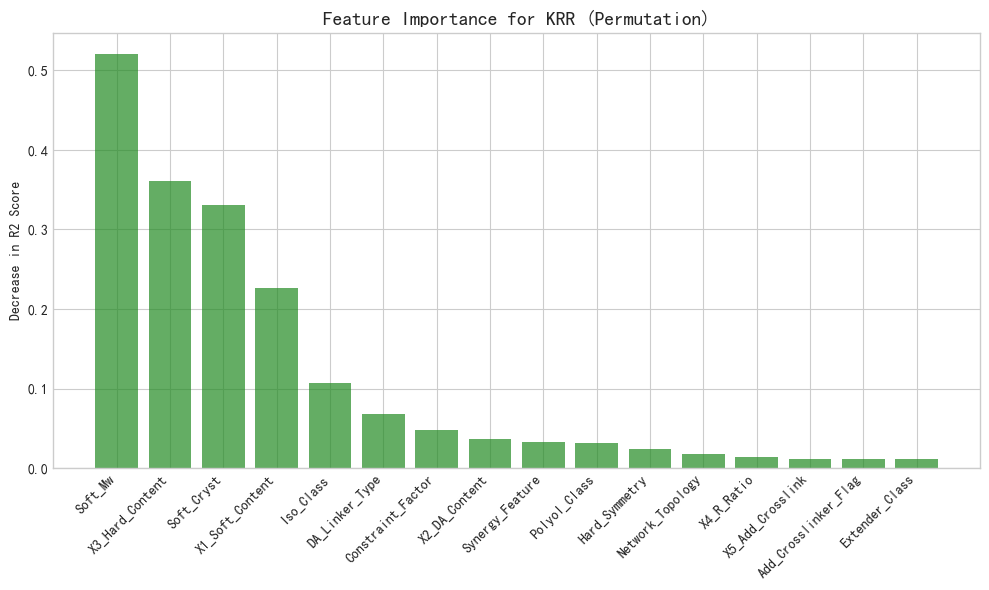

In [19]:
# --- 6. 计算特征重要性 (Permutation Importance) ---
# 必须先全量拟合一次最佳模型
best_krr.fit(X, y)

print("正在计算 KRR 的特征重要性 (Permutation)...")
result = permutation_importance(best_krr, X, y, n_repeats=30, random_state=42, scoring='r2')

# 整理结果
perm_sorted_idx = result.importances_mean.argsort()[::-1]

print("\n[KRR 特征重要性排行 (基于 R2 损失)]")
top_features_krr = []
for i in perm_sorted_idx:
    name = features[i]
    score = result.importances_mean[i]
    # 只显示正贡献的特征
    if score > 0:
        print(f"{name}: {score:.4f}")
        top_features_krr.append((name, score))

# --- 7. 绘图: 特征重要性柱状图 ---
features_plot = [x[0] for x in top_features_krr]
scores_plot = [x[1] for x in top_features_krr]

plt.figure(figsize=(10, 6))
plt.bar(range(len(features_plot)), scores_plot, color='forestgreen', alpha=0.7)
plt.xticks(range(len(features_plot)), features_plot, rotation=45, ha='right')
plt.title("Feature Importance for KRR (Permutation)", fontsize=14)
plt.ylabel("Decrease in R2 Score")
plt.tight_layout()
plt.show()

In [ ]:
# ANN
from sklearn.exceptions import ConvergenceWarning
warnings.filterwarnings("ignore", category=ConvergenceWarning)

target_col = 'tensile_strength'
features = features_mech
X, y = get_clean_data(target_col, features, df)

# --- 2. 定义参数网格 ---
# 这是一个针对小样本优化的搜索空间
param_grid = {
    'mlpregressor__hidden_layer_sizes': [(32,), (64,), (32, 16), (64, 32)], # 尝试更简单的结构
    'mlpregressor__activation': ['relu', 'tanh'],  # tanh 对回归任务有时更平滑
    'mlpregressor__solver': ['lbfgs', 'adam'],     # lbfgs 是小样本的关键！
    'mlpregressor__alpha': [0.0001, 0.001, 0.01, 0.1], # 正则化力度
    'mlpregressor__learning_rate_init': [0.001, 0.01]  # 初始学习率
}

# --- 3. 网格搜索 (GridSearchCV) ---
# 定义 Pipeline (必须标准化！)
pipe = make_pipeline(
    StandardScaler(), 
    MLPRegressor(max_iter=5000, random_state=42) # 增加迭代次数防止不收敛
)

grid_search = GridSearchCV(
    pipe, 
    param_grid, 
    cv=LeaveOneOut(), # 保持一致，使用留一法
    scoring='neg_mean_squared_error',
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X, y)

# 获取最佳模型
best_ann = grid_search.best_estimator_
best_params = grid_search.best_params_

print("\n[最佳参数组合]")
print(best_params)

# --- 4. 使用最佳参数进行最终预测 (LOOCV) ---
print("\n正在生成最终预测结果...")
y_pred_ann = cross_val_predict(best_ann, X, y, cv=LeaveOneOut(), n_jobs=-1)

# 计算指标
r2 = r2_score(y, y_pred_ann)
rmse = np.sqrt(mean_squared_error(y, y_pred_ann))

print(f"\n=== ANN (调优后) 结果 ===")
print(f"R2 Score: {r2:.4f}")
print(f"RMSE: {rmse:.4f}")

# --- 5. 绘图: 预测值 vs 真实值 ---
plt.figure(figsize=(6, 6))
plt.scatter(y, y_pred_ann, c='mediumvioletred', alpha=0.7, edgecolors='k', s=60, label='ANN Prediction')
# 画对角线
min_val, max_val = min(y.min(), y_pred_ann.min()), max(y.max(), y_pred_ann.max())
plt.plot([min_val, max_val], [min_val, max_val], 'k--', linewidth=2, label='Perfect Fit')

plt.title(f"Optimized ANN Prediction\nR2={r2:.2f}, RMSE={rmse:.2f}")
plt.xlabel("Measured Tensile Strength")
plt.ylabel("Predicted Tensile Strength")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

In [ ]:
# --- 6. 计算特征重要性 (Permutation Importance) ---
# 必须先全量拟合一次最佳模型
best_ann.fit(X, y)

print("正在计算 ANN 的特征重要性 (Permutation)...")
result = permutation_importance(best_ann, X, y, n_repeats=30, random_state=42, scoring='r2')

# 整理结果
perm_sorted_idx = result.importances_mean.argsort()[::-1]

print("\n[ANN 特征重要性排行 (基于 R2 损失)]")
top_features_ann = []
for i in perm_sorted_idx:
    name = features[i]
    score = result.importances_mean[i]
    if score > 0: # 只显示正贡献
        print(f"{name}: {score:.4f}")
        top_features_ann.append((name, score))

# --- 7. 绘图: 特征重要性柱状图 ---
features_plot = [x[0] for x in top_features_ann]
scores_plot = [x[1] for x in top_features_ann]

plt.figure(figsize=(10, 6))
plt.bar(range(len(features_plot)), scores_plot, color='mediumvioletred', alpha=0.7)
plt.xticks(range(len(features_plot)), features_plot, rotation=45, ha='right')
plt.title("Feature Importance for ANN (Permutation)", fontsize=14)
plt.ylabel("Decrease in R2 Score")
plt.tight_layout()
plt.show()

开始自动调参与模型对比，预测目标: tensile_strength (样本数: 84)
 -> MLR: 无需调参，直接使用默认模型
 -> Ridge: GridSearch(5组合) 完成, 调参CV-RMSE=7.772
 -> LASSO: GridSearch(5组合) 完成, 调参CV-RMSE=7.717
 -> SVR: RandomizedSearch(50/210组合) 完成, 调参CV-RMSE=6.999
 -> Random Forest: RandomizedSearch(50/720组合) 完成, 调参CV-RMSE=7.986
 -> XGBoost: RandomizedSearch(50/8640组合) 完成, 调参CV-RMSE=8.231
 -> GPR: GridSearch(54组合) 完成, 调参CV-RMSE=7.307
 -> MLP: RandomizedSearch(50/320组合) 完成, 调参CV-RMSE=7.030

排序后的模型性能（按 R2）：
           Model                        Route        R2       RMSE  \
0            SVR   RandomizedSearch(50/210组合)  0.763456   6.540182   
1            MLP   RandomizedSearch(50/320组合)  0.697736   7.393099   
2            GPR             GridSearch(54组合)  0.695597   7.419214   
3  Random Forest   RandomizedSearch(50/720组合)  0.673259   7.686619   
4          LASSO              GridSearch(5组合)  0.672021   7.701162   
5          Ridge              GridSearch(5组合)  0.664328   7.790965   
6        XGBoost  RandomizedSearch(50/8640组合) 

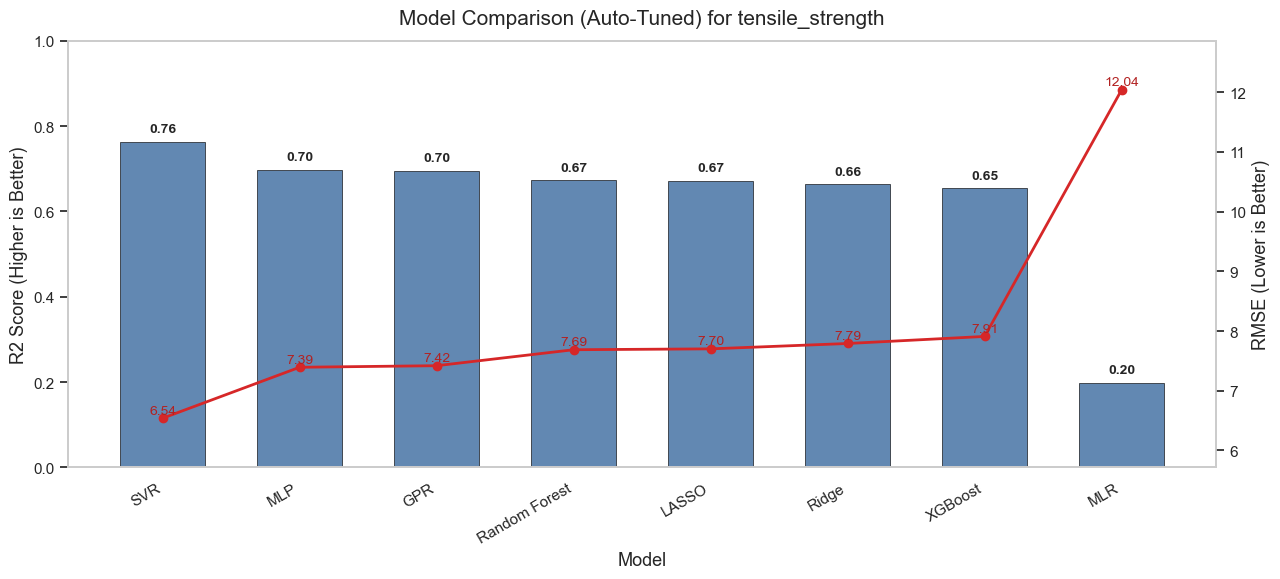


详细排名：
           Model                        Route        R2       RMSE  \
0            SVR   RandomizedSearch(50/210组合)  0.763456   6.540182   
1            MLP   RandomizedSearch(50/320组合)  0.697736   7.393099   
2            GPR             GridSearch(54组合)  0.695597   7.419214   
3  Random Forest   RandomizedSearch(50/720组合)  0.673259   7.686619   
4          LASSO              GridSearch(5组合)  0.672021   7.701162   
5          Ridge              GridSearch(5组合)  0.664328   7.790965   
6        XGBoost  RandomizedSearch(50/8640组合)  0.654066   7.909156   
7            MLR                     NoSearch  0.198754  12.036948   

   Tune_CV_RMSE  
0      6.999285  
1      7.029933  
2      7.306847  
3      7.985549  
4      7.717465  
5      7.772499  
6      8.230975  
7           NaN  


In [38]:
# 多模型能力横向对比（8种算法 + 动态路由自动调参）
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.model_selection import ParameterGrid

# 设置要预测的目标
current_target = 'tensile_strength'  # 可修改为 'elongation' 或 'healing_eff'
current_features = features_heal if current_target == 'healing_eff' else features_mech

# 获取数据
X, y = get_clean_data(current_target, current_features, df)
print(f"开始自动调参与模型对比，预测目标: {current_target} (样本数: {len(y)})")

# 统一的调参CV（避免 LOOCV 调参过慢）
tune_cv = KFold(n_splits=5, shuffle=True, random_state=42)

# 搜索路由阈值：参数组合较少时用 GridSearch，否则用 RandomizedSearch
GRID_THRESHOLD = 60
RANDOM_ITER = 50

# ---------- 定义基础模型 ----------
base_models = {
    "MLR": LinearRegression(),
    "Ridge": make_pipeline(StandardScaler(), Ridge(random_state=42)),
    "LASSO": make_pipeline(StandardScaler(), Lasso(random_state=42, max_iter=20000)),
    "SVR": make_pipeline(StandardScaler(), SVR(kernel='rbf')),
    "Random Forest": RandomForestRegressor(random_state=42, n_jobs=-1),
    "XGBoost": XGBRegressor(random_state=42, n_jobs=-1),
    "GPR": make_pipeline(
        StandardScaler(),
        GaussianProcessRegressor(
            kernel=1.0 * Matern(length_scale=1.0, length_scale_bounds=(1e-2, 1e2), nu=2.5)
            + WhiteKernel(noise_level=0.1, noise_level_bounds=(1e-5, 1e1)),
            random_state=42
        )
    ),
    "MLP": make_pipeline(StandardScaler(), MLPRegressor(random_state=42, max_iter=5000))
}

# ---------- 定义参数空间 ----------
param_spaces = {
    "MLR": {},
    "Ridge": {
        'ridge__alpha': [0.01, 0.1, 1.0, 10.0, 100.0]
    },
    "LASSO": {
        'lasso__alpha': [0.001, 0.005, 0.01, 0.05, 0.1]
    },
    "SVR": {
        'svr__C': [1, 10, 50, 100, 300, 500, 1000],
        'svr__gamma': ['scale', 0.001, 0.01, 0.1, 0.5, 1.0],
        'svr__epsilon': [0.01, 0.05, 0.1, 0.2, 0.5]
    },
    "Random Forest": {
        'n_estimators': [200, 400, 600, 800],
        'max_depth': [None, 10, 20, 30, 40],
        'min_samples_split': [2, 5, 10],
        'min_samples_leaf': [1, 2, 4],
        'max_features': ['sqrt', 'log2', 0.7, 1.0]
    },
    "XGBoost": {
        'n_estimators': [100, 200, 300, 500],
        'learning_rate': [0.01, 0.02, 0.05, 0.1],
        'max_depth': [3, 4, 5, 6, 8],
        'subsample': [0.6, 0.7, 0.8, 1.0],
        'colsample_bytree': [0.6, 0.8, 1.0],
        'reg_alpha': [0.0, 0.1, 1.0],
        'reg_lambda': [1.0, 2.0, 5.0]
    },
    "GPR": {
        'gaussianprocessregressor__kernel': [
            1.0 * Matern(length_scale=1.0, length_scale_bounds=(1e-2, 1e2), nu=1.5) + WhiteKernel(noise_level=0.1, noise_level_bounds=(1e-5, 1e1)),
            1.0 * Matern(length_scale=1.0, length_scale_bounds=(1e-2, 1e2), nu=2.5) + WhiteKernel(noise_level=0.1, noise_level_bounds=(1e-5, 1e1)),
            1.0 * RBF(length_scale=1.0, length_scale_bounds=(1e-2, 1e2)) + WhiteKernel(noise_level=0.1, noise_level_bounds=(1e-5, 1e1))
        ],
        'gaussianprocessregressor__alpha': [1e-10, 1e-6, 1e-4],
        'gaussianprocessregressor__normalize_y': [True, False],
        'gaussianprocessregressor__n_restarts_optimizer': [0, 5, 10]
    },
    "MLP": {
        'mlpregressor__hidden_layer_sizes': [(32,), (64,), (128,), (64, 32), (128, 64)],
        'mlpregressor__activation': ['relu', 'tanh'],
        'mlpregressor__solver': ['lbfgs', 'adam'],
        'mlpregressor__alpha': [0.0001, 0.001, 0.01, 0.1],
        'mlpregressor__learning_rate_init': [0.0005, 0.001, 0.005, 0.01]
    }
}


def tune_model_with_dynamic_route(model_name, base_model, param_space, X_train, y_train):
    """
    根据参数空间大小，自动选择 GridSearch 或 RandomizedSearch。
    """
    if not param_space:
        print(f" -> {model_name}: 无需调参，直接使用默认模型")
        return base_model, "NoSearch", {}, np.nan

    total_combinations = len(list(ParameterGrid(param_space)))

    if total_combinations <= GRID_THRESHOLD:
        search = GridSearchCV(
            estimator=base_model,
            param_grid=param_space,
            cv=tune_cv,
            scoring='neg_mean_squared_error',
            n_jobs=-1,
            verbose=0
        )
        route = f"GridSearch({total_combinations}组合)"
    else:
        n_iter = min(RANDOM_ITER, total_combinations)
        search = RandomizedSearchCV(
            estimator=base_model,
            param_distributions=param_space,
            n_iter=n_iter,
            cv=tune_cv,
            scoring='neg_mean_squared_error',
            random_state=42,
            n_jobs=-1,
            verbose=0
        )
        route = f"RandomizedSearch({n_iter}/{total_combinations}组合)"

    search.fit(X_train, y_train)

    best_model = search.best_estimator_
    best_params = search.best_params_
    best_rmse_cv = np.sqrt(-search.best_score_)

    print(f" -> {model_name}: {route} 完成, 调参CV-RMSE={best_rmse_cv:.3f}")
    return best_model, route, best_params, best_rmse_cv


results = []
best_models = {}

for name in base_models.keys():
    tuned_model, route_used, best_params, tune_rmse = tune_model_with_dynamic_route(
        name, base_models[name], param_spaces[name], X, y
    )

    r2, rmse, _ = evaluate_model(tuned_model, X, y)
    best_models[name] = tuned_model

    results.append({
        "Model": name,
        "Route": route_used,
        "R2": r2,
        "RMSE": rmse,
        "Tune_CV_RMSE": tune_rmse,
        "Best_Params": best_params
    })

# ---------- 汇总与排序 ----------
res_df = pd.DataFrame(results).sort_values(by="R2", ascending=False).reset_index(drop=True)

print("\n排序后的模型性能（按 R2）：")
print(res_df[["Model", "Route", "R2", "RMSE", "Tune_CV_RMSE"]])

print("\n各模型最优参数：")
for _, row in res_df.iterrows():
    print(f"\n[{row['Model']}] {row['Route']}")
    print(row["Best_Params"])

# --- 绘图部分（保证柱状图与折线顺序一致） ---
fig, ax1 = plt.subplots(figsize=(13, 6))
x_pos = np.arange(len(res_df))

# R2兜底显示：限制在[0, 1]，避免负值影响学术图展示
r2_plot = res_df['R2'].clip(lower=0, upper=1)

# 柱状图：R2
ax1.bar(x_pos, r2_plot, alpha=0.88, width=0.62, color='#4C78A8', edgecolor='black', linewidth=0.5)
ax1.set_xlabel("Model", fontsize=13)
ax1.set_ylabel("R2 Score (Higher is Better)", fontsize=13)
ax1.set_ylim(0, 1.0)
ax1.set_xticks(x_pos)
ax1.set_xticklabels(res_df['Model'], rotation=30, ha='right', fontsize=11)
ax1.tick_params(axis='y', labelsize=11)

for i, r2 in enumerate(r2_plot):
    if r2 > 0:
        ax1.text(i, min(r2 + 0.015, 0.985), f"{r2:.2f}", ha='center', va='bottom', fontsize=10, fontweight='bold')

# 右轴：RMSE
ax2 = ax1.twinx()
ax2.plot(x_pos, res_df['RMSE'], marker='o', linewidth=2.0, linestyle='-', color='#D62728')
ax2.set_ylabel("RMSE (Lower is Better)", fontsize=13)
ax2.tick_params(axis='y', labelsize=11)
rmse_min, rmse_max = res_df['RMSE'].min(), res_df['RMSE'].max()
pad = (rmse_max - rmse_min) * 0.15 if rmse_max != rmse_min else 1.0
ax2.set_ylim(rmse_min - pad, rmse_max + pad)

for i, rmse in enumerate(res_df['RMSE']):
    ax2.text(i, rmse + (pad * 0.03), f"{rmse:.2f}", ha='center', va='bottom', color='#B22222', fontsize=10)

plt.title(f"Model Comparison (Auto-Tuned) for {current_target}", fontsize=15, pad=12)
ax1.grid(False)
ax2.grid(False)
fig.tight_layout(pad=1.2)
plt.show()

print("\n详细排名：")
print(res_df[["Model", "Route", "R2", "RMSE", "Tune_CV_RMSE"]])

# 为汇总对比创建别名
res_df_tensile = res_df

开始自动调参与模型对比,预测目标: elongation (样本数: 84)
 -> MLR: 无需调参，直接使用默认模型
 -> Ridge: GridSearch(5组合) 完成, 调参CV-RMSE=209.063
 -> LASSO: GridSearch(5组合) 完成, 调参CV-RMSE=210.738
 -> SVR: RandomizedSearch(50/210组合) 完成, 调参CV-RMSE=169.296
 -> Random Forest: RandomizedSearch(50/720组合) 完成, 调参CV-RMSE=175.009
 -> XGBoost: RandomizedSearch(50/8640组合) 完成, 调参CV-RMSE=166.894
 -> GPR: GridSearch(54组合) 完成, 调参CV-RMSE=169.171
 -> MLP: RandomizedSearch(50/320组合) 完成, 调参CV-RMSE=181.329

排序后的模型性能(按 R2):
           Model                        Route         R2         RMSE  \
0        XGBoost  RandomizedSearch(50/8640组合)   0.655000   158.377855   
1            SVR   RandomizedSearch(50/210组合)   0.607871   168.849165   
2            GPR             GridSearch(54组合)   0.607377   168.955665   
3  Random Forest   RandomizedSearch(50/720组合)   0.594619   171.678697   
4            MLP   RandomizedSearch(50/320组合)   0.546354   181.611510   
5          Ridge              GridSearch(5组合)   0.422256   204.952092   
6          LASSO 

TypeError: text() missing 1 required positional argument: 's'

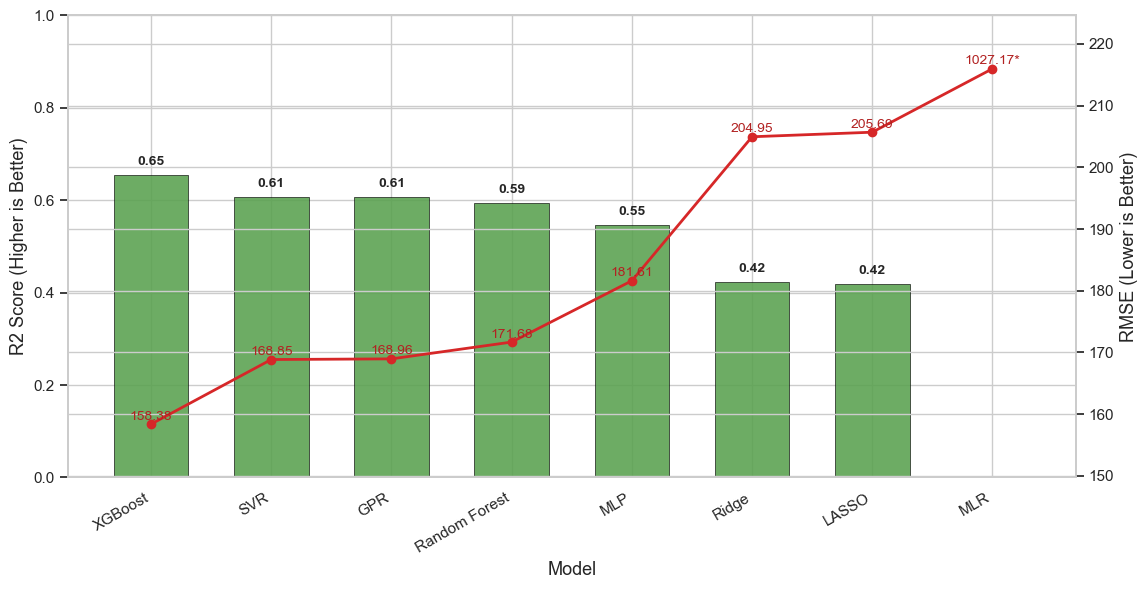

In [ ]:
# 多模型能力横向对比: elongation(8种算法 + 动态路由自动调参)

# 设置要预测的目标
current_target = 'elongation'
current_features = features_mech

# 获取数据
X, y = get_clean_data(current_target, current_features, df)
print(f"开始自动调参与模型对比,预测目标: {current_target} (样本数: {len(y)})")

# 复用之前定义的基础模型和参数空间
results_elong = []
best_models_elong = {}

for name in base_models.keys():
    tuned_model, route_used, best_params, tune_rmse = tune_model_with_dynamic_route(
        name, base_models[name], param_spaces[name], X, y
    )
    r2, rmse, _ = evaluate_model(tuned_model, X, y)
    best_models_elong[name] = tuned_model
    results_elong.append({
        "Model": name, "Route": route_used, "R2": r2, "RMSE": rmse,
        "Tune_CV_RMSE": tune_rmse, "Best_Params": best_params
    })

res_df_elong = pd.DataFrame(results_elong).sort_values(by="R2", ascending=False).reset_index(drop=True)
print("\n排序后的模型性能(按 R2):")
print(res_df_elong[["Model", "Route", "R2", "RMSE", "Tune_CV_RMSE"]])

print("\n各模型最优参数:")
for _, row in res_df_elong.iterrows():
    print(f"\n[{row['Model']}] {row['Route']}")
    print(row["Best_Params"])

# 绘图
fig, ax1 = plt.subplots(figsize=(13, 6))
x_pos = np.arange(len(res_df_elong))

# R2兜底显示：限制在[0, 1]，避免负值影响学术图展示
r2_plot = res_df_elong['R2'].clip(lower=0, upper=1)

ax1.bar(x_pos, r2_plot, alpha=0.88, width=0.62, color='#59A14F', edgecolor='black', linewidth=0.5)
ax1.set_xlabel("Model", fontsize=13)
ax1.set_ylabel("R2 Score (Higher is Better)", fontsize=13)
ax1.set_ylim(0, 1.0)
ax1.set_xticks(x_pos)
ax1.set_xticklabels(res_df_elong['Model'], rotation=30, ha='right', fontsize=11)
ax1.tick_params(axis='y', labelsize=11)
for i, r2 in enumerate(r2_plot):
    if r2 > 0:
        ax1.text(i, min(r2 + 0.015, 0.985), f"{r2:.2f}", ha='center', va='bottom', fontsize=10, fontweight='bold')

ax2 = ax1.twinx()

# RMSE仅用于绘图的兜底显示：截断极端值，保留原始结果表不变
rmse_raw = res_df_elong['RMSE'].copy()
rmse_cap = rmse_raw.nlargest(2).iloc[-1] * 1.05 if len(rmse_raw) > 1 else rmse_raw.max()
rmse_plot = rmse_raw.clip(upper=rmse_cap)
is_capped = rmse_raw > rmse_cap

ax2.plot(x_pos, rmse_plot, marker='o', linewidth=2.0, linestyle='-', color='#D62728')
ax2.set_ylabel("RMSE (Lower is Better)", fontsize=13)
ax2.tick_params(axis='y', labelsize=11)
rmse_min, rmse_max = rmse_plot.min(), rmse_plot.max()
pad = (rmse_max - rmse_min) * 0.15 if rmse_max != rmse_min else 1.0
ax2.set_ylim(rmse_min - pad, rmse_max + pad)

for i, (rmse_disp, rmse_true, capped) in enumerate(zip(rmse_plot, rmse_raw, is_capped)):
    label = f"{rmse_true:.2f}*" if capped else f"{rmse_true:.2f}"
    ax2.text(i, rmse_disp + (pad * 0.03), label, ha='center', va='bottom', color='#B22222', fontsize=10)

if is_capped.any():
    ax2.text(
        0.99, 0.98,
        f"* RMSE capped at {rmse_cap:.2f} for display only",
        transform=ax2.transAxes, ha='right', va='top',
        fontsize=9, color='#8B0000'
    )

plt.title(f"Model Comparison (Auto-Tuned) for {current_target}", fontsize=15, pad=12)
ax1.grid(False)
ax2.grid(False)
fig.tight_layout(pad=1.2)
plt.show()

print("\n详细排名:")
print(res_df_elong[["Model", "Route", "R2", "RMSE", "Tune_CV_RMSE"]])

开始自动调参与模型对比,预测目标: healing_eff (样本数: 37)
 -> MLR: 无需调参，直接使用默认模型
 -> Ridge: GridSearch(5组合) 完成, 调参CV-RMSE=6.352
 -> LASSO: GridSearch(5组合) 完成, 调参CV-RMSE=6.687
 -> SVR: RandomizedSearch(50/210组合) 完成, 调参CV-RMSE=6.169
 -> Random Forest: RandomizedSearch(50/720组合) 完成, 调参CV-RMSE=6.362
 -> XGBoost: RandomizedSearch(50/8640组合) 完成, 调参CV-RMSE=6.686
 -> GPR: GridSearch(54组合) 完成, 调参CV-RMSE=5.276
 -> MLP: RandomizedSearch(50/320组合) 完成, 调参CV-RMSE=6.354

排序后的模型性能(按 R2):
           Model                        Route        R2      RMSE  \
0            GPR             GridSearch(54组合)  0.807894  5.298369   
1            SVR   RandomizedSearch(50/210组合)  0.794798  5.475997   
2  Random Forest   RandomizedSearch(50/720组合)  0.765722  5.851106   
3            MLR                     NoSearch  0.745251  6.101380   
4          Ridge              GridSearch(5组合)  0.712261  6.484416   
5        XGBoost  RandomizedSearch(50/8640组合)  0.711455  6.493501   
6          LASSO              GridSearch(5组合)  0.694974  6

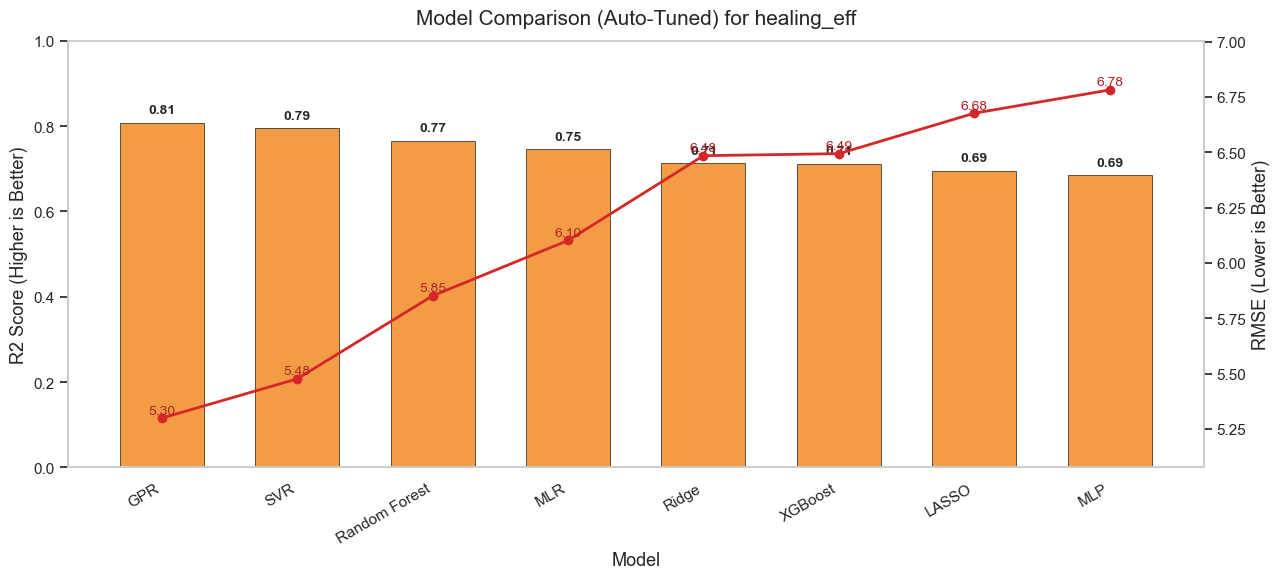


详细排名:
           Model                        Route        R2      RMSE  \
0            GPR             GridSearch(54组合)  0.807894  5.298369   
1            SVR   RandomizedSearch(50/210组合)  0.794798  5.475997   
2  Random Forest   RandomizedSearch(50/720组合)  0.765722  5.851106   
3            MLR                     NoSearch  0.745251  6.101380   
4          Ridge              GridSearch(5组合)  0.712261  6.484416   
5        XGBoost  RandomizedSearch(50/8640组合)  0.711455  6.493501   
6          LASSO              GridSearch(5组合)  0.694974  6.676368   
7            MLP   RandomizedSearch(50/320组合)  0.685287  6.781557   

   Tune_CV_RMSE  
0      5.275648  
1      6.168522  
2      6.362289  
3           NaN  
4      6.351706  
5      6.686244  
6      6.687379  
7      6.354295  


In [40]:
# 多模型能力横向对比: healing_eff(8种算法 + 动态路由自动调参)

# 设置要预测的目标
current_target = 'healing_eff'
current_features = features_heal  # 注意: healing_eff 需要包含温度和时间特征

# 获取数据
X, y = get_clean_data(current_target, current_features, df)
print(f"开始自动调参与模型对比,预测目标: {current_target} (样本数: {len(y)})")

# 复用之前定义的基础模型和参数空间
results_heal = []
best_models_heal = {}

for name in base_models.keys():
    tuned_model, route_used, best_params, tune_rmse = tune_model_with_dynamic_route(
        name, base_models[name], param_spaces[name], X, y
    )
    r2, rmse, _ = evaluate_model(tuned_model, X, y)
    best_models_heal[name] = tuned_model
    results_heal.append({
        "Model": name, "Route": route_used, "R2": r2, "RMSE": rmse,
        "Tune_CV_RMSE": tune_rmse, "Best_Params": best_params
    })

res_df_heal = pd.DataFrame(results_heal).sort_values(by="R2", ascending=False).reset_index(drop=True)
print("\n排序后的模型性能(按 R2):")
print(res_df_heal[["Model", "Route", "R2", "RMSE", "Tune_CV_RMSE"]])

print("\n各模型最优参数:")
for _, row in res_df_heal.iterrows():
    print(f"\n[{row['Model']}] {row['Route']}")
    print(row["Best_Params"])

# 绘图
fig, ax1 = plt.subplots(figsize=(13, 6))
x_pos = np.arange(len(res_df_heal))

# R2兜底显示：限制在[0, 1]，避免负值影响学术图展示
r2_plot = res_df_heal['R2'].clip(lower=0, upper=1)

ax1.bar(x_pos, r2_plot, alpha=0.88, width=0.62, color='#F28E2B', edgecolor='black', linewidth=0.5)
ax1.set_xlabel("Model", fontsize=13)
ax1.set_ylabel("R2 Score (Higher is Better)", fontsize=13)
ax1.set_ylim(0, 1.0)
ax1.set_xticks(x_pos)
ax1.set_xticklabels(res_df_heal['Model'], rotation=30, ha='right', fontsize=11)
ax1.tick_params(axis='y', labelsize=11)
for i, r2 in enumerate(r2_plot):
    if r2 > 0:
        ax1.text(i, min(r2 + 0.015, 0.985), f"{r2:.2f}", ha='center', va='bottom', fontsize=10, fontweight='bold')

ax2 = ax1.twinx()
ax2.plot(x_pos, res_df_heal['RMSE'], marker='o', linewidth=2.0, linestyle='-', color='#D62728')
ax2.set_ylabel("RMSE (Lower is Better)", fontsize=13)
ax2.tick_params(axis='y', labelsize=11)
rmse_min, rmse_max = res_df_heal['RMSE'].min(), res_df_heal['RMSE'].max()
pad = (rmse_max - rmse_min) * 0.15 if rmse_max != rmse_min else 1.0
ax2.set_ylim(rmse_min - pad, rmse_max + pad)
for i, rmse in enumerate(res_df_heal['RMSE']):
    ax2.text(i, rmse + (pad * 0.03), f"{rmse:.2f}", ha='center', va='bottom', color='#B22222', fontsize=10)

plt.title(f"Model Comparison (Auto-Tuned) for {current_target}", fontsize=15, pad=12)
ax1.grid(False)
ax2.grid(False)
fig.tight_layout(pad=1.2)
plt.show()

print("\n详细排名:")
print(res_df_heal[["Model", "Route", "R2", "RMSE", "Tune_CV_RMSE"]])

In [30]:
# ============================================
# 三目标综合对比汇总
# ============================================

# 提取每个目标的前3名模型
summary_data = []

# Tensile Strength 前3名
for idx, row in res_df_tensile.head(3).iterrows():
    summary_data.append({
        '目标': 'tensile_strength',
        '排名': idx+1,
        '模型': row['Model'],
        'R²': row['R2'],
        'RMSE': row['RMSE'],
        '调参路由': row['Route']
    })

# Elongation 前3名
for idx, row in res_df_elong.head(3).iterrows():
    summary_data.append({
        '目标': 'elongation',
        '排名': idx+1,
        '模型': row['Model'],
        'R²': row['R2'],
        'RMSE': row['RMSE'],
        '调参路由': row['Route']
    })

# Healing Efficiency 前3名
for idx, row in res_df_heal.head(3).iterrows():
    summary_data.append({
        '目标': 'healing_eff',
        '排名': idx+1,
        '模型': row['Model'],
        'R²': row['R2'],
        'RMSE': row['RMSE'],
        '调参路由': row['Route']
    })

summary_df = pd.DataFrame(summary_data)

print("="*80)
print("三目标自动调参最优模型综合对比 (Top 3 for Each Target)")
print("="*80)
print(summary_df.to_string(index=False))
print("\n")

# 最优模型总结
print("="*80)
print("各目标最优模型总结")
print("="*80)
print(f"1. [tensile_strength] 最优: {res_df_tensile.iloc[0]['Model']} (R²={res_df_tensile.iloc[0]['R2']:.3f}, RMSE={res_df_tensile.iloc[0]['RMSE']:.2f})")
print(f"2. [elongation]       最优: {res_df_elong.iloc[0]['Model']} (R²={res_df_elong.iloc[0]['R2']:.3f}, RMSE={res_df_elong.iloc[0]['RMSE']:.2f})")
print(f"3. [healing_eff]      最优: {res_df_heal.iloc[0]['Model']} (R²={res_df_heal.iloc[0]['R2']:.3f}, RMSE={res_df_heal.iloc[0]['RMSE']:.2f})")
print("="*80)

三目标自动调参最优模型综合对比 (Top 3 for Each Target)
              目标  排名            模型       R²       RMSE                        调参路由
tensile_strength   1           SVR 0.763456   6.540182  RandomizedSearch(50/210组合)
tensile_strength   2           MLP 0.697736   7.393099  RandomizedSearch(50/320组合)
tensile_strength   3           GPR 0.695597   7.419214            GridSearch(54组合)
      elongation   1       XGBoost 0.655000 158.377855 RandomizedSearch(50/8640组合)
      elongation   2           SVR 0.607871 168.849165  RandomizedSearch(50/210组合)
      elongation   3           GPR 0.607377 168.955665            GridSearch(54组合)
     healing_eff   1           GPR 0.807894   5.298369            GridSearch(54组合)
     healing_eff   2           SVR 0.794798   5.475997  RandomizedSearch(50/210组合)
     healing_eff   3 Random Forest 0.765722   5.851106  RandomizedSearch(50/720组合)


各目标最优模型总结
1. [tensile_strength] 最优: SVR (R²=0.763, RMSE=6.54)
2. [elongation]       最优: XGBoost (R²=0.655, RMSE=158.38)
3. [heal